## Implementasi Ensemble Boosting dengan  AdaBoost, Gradient Boosting, dan XGBoost.

In [2]:
#1. Import Library

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

In [3]:
#2. Load Open Dataset
# Kita gunakan dataset Breast Cancer dari sklearn:
# Load dataset


data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
#3. Model Baseline (Decision Tree)

baseline_model = DecisionTreeClassifier(max_depth=1, random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
print("=== Baseline Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Precision:", precision_score(y_test, y_pred_baseline))
print("Recall:", recall_score(y_test, y_pred_baseline))
print("F1 Score:", f1_score(y_test, y_pred_baseline))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_baseline))

=== Baseline Decision Tree ===
Accuracy: 0.9210526315789473
Precision: 0.92
Recall: 0.9583333333333334
F1 Score: 0.9387755102040817
Confusion Matrix:
 [[36  6]
 [ 3 69]]


In [5]:
#4. AdaBoost Implementation

adaboost = AdaBoostClassifier(
estimator=DecisionTreeClassifier(max_depth=1),
n_estimators=100,
learning_rate=0.5,
random_state=42
)
adaboost.fit(X_train, y_train)
y_pred_ada = adaboost.predict(X_test)
print("\n=== AdaBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada))
print("Recall:", recall_score(y_test, y_pred_ada))
print("F1 Score:", f1_score(y_test, y_pred_ada))


=== AdaBoost ===
Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1 Score: 0.9659863945578231


In [6]:
#5. Gradient Boosting Implementation

gb = GradientBoostingClassifier(
n_estimators=100,
learning_rate=0.1,
max_depth=3,
random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("\n=== Gradient Boosting ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))


=== Gradient Boosting ===
Accuracy: 0.956140350877193
Precision: 0.9466666666666667
Recall: 0.9861111111111112
F1 Score: 0.9659863945578231


In [9]:
#6. XGBoost Implementation

xgb = XGBClassifier(
n_estimators=100,
learning_rate=0.1,
max_depth=3,
random_state=42,
use_label_encoder=False,
eval_metric='logloss'
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("\n=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))


=== XGBoost ===
Accuracy: 0.9473684210526315
Precision: 0.9459459459459459
Recall: 0.9722222222222222
F1 Score: 0.958904109589041


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:12:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [10]:
#7. Perbandingan Hasil Model
results = pd.DataFrame({
'Model': ['Decision Tree', 'AdaBoost', 'Gradient Boosting', 'XGBoost'],
'Accuracy': [
accuracy_score(y_test, y_pred_baseline),
accuracy_score(y_test, y_pred_ada),
accuracy_score(y_test, y_pred_gb),
accuracy_score(y_test, y_pred_xgb)
],
'Precision': [
precision_score(y_test, y_pred_baseline),
precision_score(y_test, y_pred_ada),
precision_score(y_test, y_pred_gb),
precision_score(y_test, y_pred_xgb)
],
'Recall': [
recall_score(y_test, y_pred_baseline),
recall_score(y_test, y_pred_ada),
recall_score(y_test, y_pred_gb),
recall_score(y_test, y_pred_xgb)
],
'F1 Score': [
f1_score(y_test, y_pred_baseline),
f1_score(y_test, y_pred_ada),
f1_score(y_test, y_pred_gb),
f1_score(y_test, y_pred_xgb)
]
})
print("\n=== Perbandingan Model Boosting ===")
print(results)


=== Perbandingan Model Boosting ===
               Model  Accuracy  Precision    Recall  F1 Score
0      Decision Tree  0.921053   0.920000  0.958333  0.938776
1           AdaBoost  0.956140   0.946667  0.986111  0.965986
2  Gradient Boosting  0.956140   0.946667  0.986111  0.965986
3            XGBoost  0.947368   0.945946  0.972222  0.958904


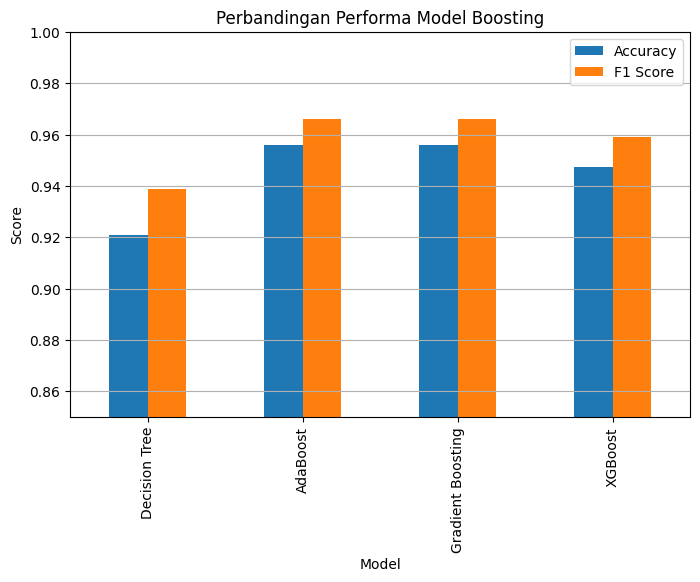

In [11]:
# 8. (Opsional) Visualisasi Hasil

import matplotlib.pyplot as plt
results.set_index('Model')[['Accuracy', 'F1 Score']].plot(kind='bar', figsize=(8,5))
plt.title("Perbandingan Performa Model Boosting")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.grid(axis='y')
plt.show()